# NLP Fake News Classification Experiment

This notebook builds a Natural Language Processing pipeline to classify news articles as real or fake. The target column uses `0 = Real News` and `1 = Fake News`.

The pipeline follows these steps:

1. Load and explore the dataset
2. Clean and preprocess text
3. Split data into training and testing sets
4. Convert text into TF-IDF features
5. Add sentiment scores using TextBlob
6. Combine TF-IDF and sentiment features
7. Train a Random Forest model
8. Evaluate model performance

In [1]:
import re

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from textblob import TextBlob

In [2]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nathn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nathn\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\nathn\AppData\Roaming\nltk_data...


True

In [3]:
df = pd.read_csv("data/fake_news.csv")

df.head()

,title,text,subject,date,label
0,WOW! LOU DOBBS BLASTS #FakePresident OBAMA: “S...,Lou Dobbs went off on #FakePresident Barack Ob...,politics,2017-07-11,0
1,President WATCH: FUNNIEST Done ‘Couch Commande...,For his final White House Correspondent s Dinn...,News,2016-04-30,0
2,RELIGION OF PROGRESSIVISM: Meet Obama’s NEW Tr...,The religion of Progressivism is working overt...,politics,2016-05-17,0
3,Breitbart Caught Praising Melania For Exact T...,In a stunning example of just how morally bank...,News,2017-05-21,0
4,HOST SICKENING! MOCKS Jeff Grandchildren Senat...,,politics,2017-01-10,0


In [4]:
# View dataset shape
print(df.shape)

# View column names
print(df.columns)

# Check missing values
print(df.isnull().sum())

# Check class distribution
print(df["label"].value_counts())

(2500, 5)
Index(['title', 'text', 'subject', 'date', 'label'], dtype='str')
title      0
text       0
subject    0
date       1
label      0
dtype: int64
label
0    1307
1    1193
Name: count, dtype: int64


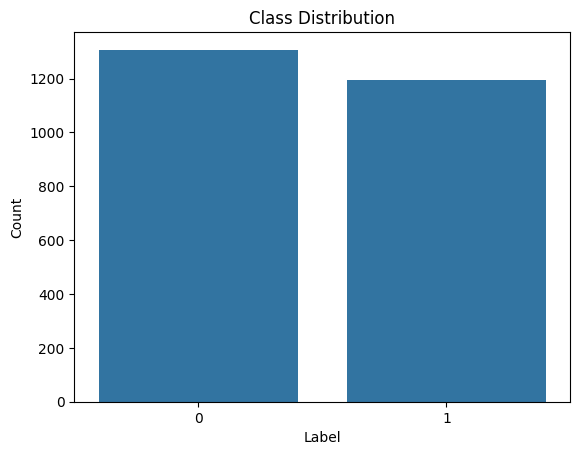

In [5]:
sns.countplot(x="label", data=df)

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [6]:
# Create lemmatizer and stopword list
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

In [7]:
def clean_text(text):
    """
    Cleans and preprocesses text data.
    """

    # Convert to lowercase
    text = text.lower()

    # Remove non-alphabetic characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenize
    words = text.split()

    # Remove stopwords and lemmatize
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back into text
    return " ".join(cleaned_words)

In [8]:
df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text", "label"]].head()

,text,clean_text,label
0,Lou Dobbs went off on #FakePresident Barack Ob...,lou dobbs went fakepresident barack obama dobb...,0
1,For his final White House Correspondent s Dinn...,final white house correspondent dinner white h...,0
2,The religion of Progressivism is working overt...,religion progressivism working overtime erase ...,0
3,In a stunning example of just how morally bank...,stunning example morally bankrupt rightwing me...,0
4,,,0


In [9]:
# Remove rows with empty cleaned text
df = df[df["clean_text"].str.strip() != ""]

# Check updated shape
print(df.shape)

(2459, 6)


In [10]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1967
Testing rows: 492


In [11]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (1967, 5000)
Testing TF-IDF shape: (492, 5000)


In [12]:
# Create sentiment scores
train_sentiment = X_train.apply(
    lambda text: TextBlob(text).sentiment.polarity
)

test_sentiment = X_test.apply(
    lambda text: TextBlob(text).sentiment.polarity
)

print(train_sentiment.head())

1312   -0.006331
2042    0.086111
175    -0.203150
1087    0.102586
803     0.006180
Name: clean_text, dtype: float64


In [13]:
from scipy.sparse import hstack

X_train_combined = hstack([
    X_train_tfidf,
    train_sentiment.values.reshape(-1, 1)
])

X_test_combined = hstack([
    X_test_tfidf,
    test_sentiment.values.reshape(-1, 1)
])

print("Training combined shape:", X_train_combined.shape)
print("Testing combined shape:", X_test_combined.shape)

Training combined shape: (1967, 5001)
Testing combined shape: (492, 5001)


In [14]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_combined, y_train)

print("Model training complete.")

Model training complete.


In [15]:
y_pred = model.predict(X_test_combined)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       253
           1       0.98      0.99      0.99       239

    accuracy                           0.99       492
   macro avg       0.99      0.99      0.99       492
weighted avg       0.99      0.99      0.99       492



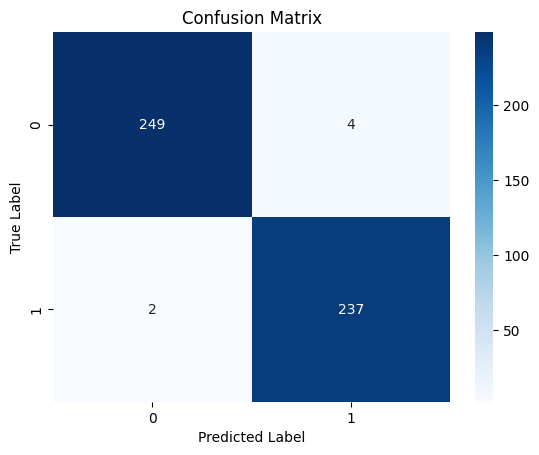

In [16]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Results Discussion

The Random Forest classifier performed very well on this dataset with an accuracy close to 99%. Both precision and recall scores were very high, which means the model was able to correctly identify both real and fake news articles with very few mistakes.

TF-IDF worked well for feature extraction because it converted text into numerical values based on word importance. Words that appeared frequently in one article but not across all articles became more useful for classification. This helped the model identify patterns commonly found in fake or real news articles.

One challenge during preprocessing was cleaning the text data while still preserving meaningful information. Removing punctuation, stopwords, and non-alphabetic characters can sometimes remove context from sentences. Another issue was that some rows became empty after preprocessing and needed to be removed.

The Random Forest model performed better than expected on this dataset. One reason may be that the dataset contains strong wording patterns that clearly separate fake and real news articles.